In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = False

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2784105628.404928, 80541754.25855352, 164244674.8365474, 200830056.3125612, 203040110.80845094, 203139662.18068352, 203155691.37177274, 203162030.57708424, 203165876.37488377, 203168766.53285336, 203170807.10262024, 203172426.20489404, 203173653.1666933, 203174661.15127578, 203175563.79442886, 203176388.8982932, 203177156.52639475, 203177899.84723285, 203178676.43458796, 203179395.2495648, 203179910.8367752, 203180433.83821186, 203181013.5808989, 203181607.8707297, 203182028.5402568, 203182447.90348464, 203182952.80473882, 203183418.0742293, 203183749.0344772, 203184155.11052918, 203184566.69445956, 203184829.44437984, 203185090.53536883, 203185410.53253645, 203185774.6269063, 203186001.5671821, 203186201.93955007, 203186401.13167983, 203186607.00852236, 203186810.12100628, 203186995.76521987, 203187172.94687617, 203187371.33464625, 203187637.77496946, 203187913.376968, 203188007.90618184, 

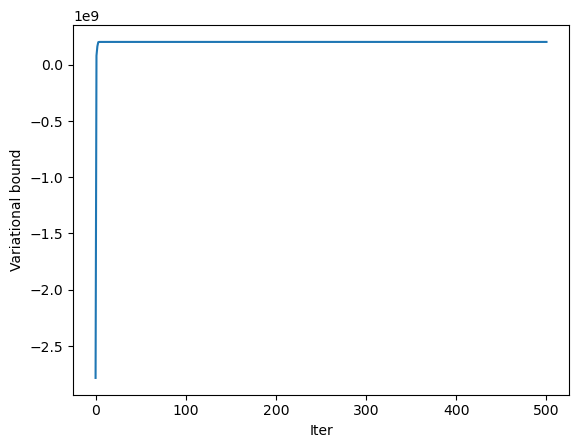

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-10
verbose = False

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with last mode completely masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2651132242.5099363, 82082179.42780375, 162077652.1433464, 197880277.59275022, 201326000.2408265, 202085864.8246412, 202192652.59012413, 202211650.52741858, 202217841.11493185, 202221333.98275733, 202223577.2245314, 202225484.19873857, 202227250.49500847, 202228530.62991625, 202229588.16698977, 202230538.19629294, 202231343.5491262, 202231899.45411184, 202232358.05042765, 202232848.66004822, 202233400.46531686, 202233910.8828111, 202234237.67070243, 202234562.19491398, 202234891.8896806, 202235234.79266658, 202235611.92650825, 202236072.05605003, 202236491.97303402, 202236767.3763965, 202237097.03592855, 202237526.4451576, 202237879.67263472, 202238166.47066396, 202238551.4672099, 202238860.30832857, 202239095.77573907, 202239418.96502712, 202239681.78534517, 202239803.00195482, 202239935.52006018, 202240083.84990272, 202240250.34282735, 202240444.97040272, 202240688.22254762, 202240976.3246

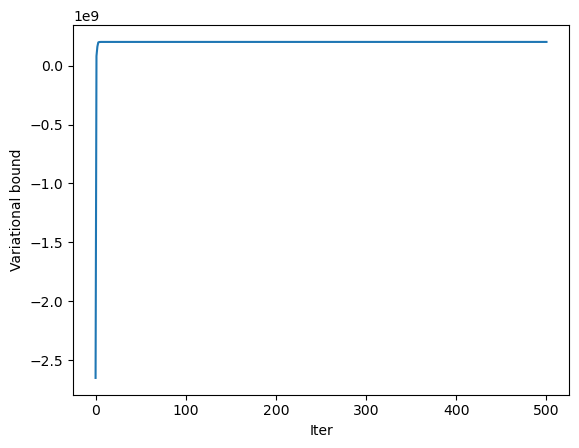

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with the 1st and 3rd indices masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2820719636.9031644, 83905211.906612, 168667461.49173522, 199401955.12083533, 202103164.60635582, 202220335.57660627, 202235217.5507483, 202239732.46074358, 202242246.8235656, 202243903.5329279, 202245103.1075128, 202246225.04298934, 202247312.20959958, 202248187.50309435, 202249021.69710067, 202249615.37573344, 202250121.38693774, 202250623.4948409, 202251130.8118285, 202251672.15291283, 202252318.48003712, 202252935.37464082, 202253312.2547874, 202253585.28549013, 202253841.98117366, 202254089.06005836, 202254336.1777563, 202254575.84919775, 202254809.50334817, 202255090.83860514, 202255391.47767112, 202255668.2953179, 202255958.26985958, 202256303.7742707, 202256650.4323727, 202256831.98921102, 202256965.7561633, 202257103.58098385, 202257248.00704867, 202257392.47417575, 202257528.01210898, 202257658.74915722, 202257784.51654562, 202257911.21718556, 202258041.3535072, 202258177.20315304,

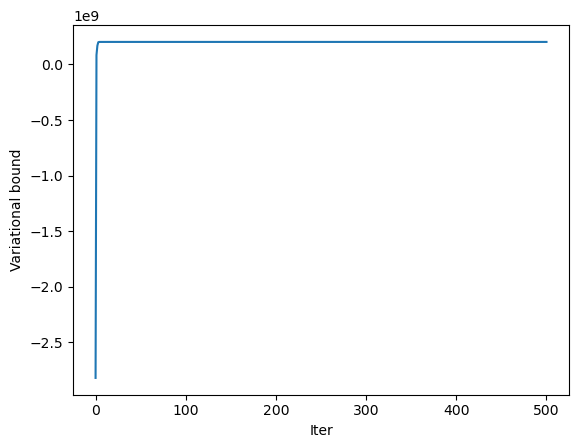

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# Mask with only diagonals masked

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2873345573.595352, 80534314.54766504, 162393234.60265467, 197352472.70502698, 202746898.32043475, 203148171.42643335, 203173337.73128, 203180972.54849562, 203185111.38335472, 203187773.95038235, 203189914.41769832, 203191693.20552304, 203193071.97690758, 203193984.42805448, 203194753.569449, 203195440.4152231, 203196061.32105246, 203196619.49276376, 203197117.08796415, 203197570.55523658, 203197982.7939069, 203198362.94328526, 203198721.59315157, 203199063.3238969, 203199392.40365517, 203199716.87059927, 203200055.40815568, 203200443.69528475, 203200827.3928557, 203201031.21490273, 203201201.04100636, 203201362.69130304, 203201524.5210472, 203201682.21521282, 203201836.26528332, 203201987.51650003, 203202135.3821426, 203202278.76966643, 203202415.01866832, 203202549.79204363, 203202684.3139506, 203202818.87774023, 203202956.55457133, 203203102.13378727, 203203263.29059696, 203203445.906706,

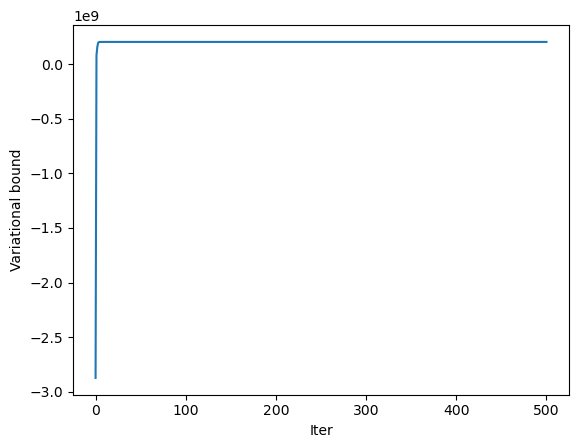

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=verbose, tol=tol)

# No mask

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-2856018383.9929805, 80909458.37677078, 165323099.61271718, 199191061.8955264, 203427786.03154144, 203686780.95053637, 203712132.859162, 203719352.93104458, 203723375.03392288, 203726049.83287928, 203728197.84457588, 203729954.6278085, 203731234.89172503, 203732322.93949696, 203733310.21202627, 203734213.87408888, 203735128.5158378, 203736094.98656315, 203737021.56338164, 203737788.05602407, 203738354.8993759, 203738777.8303981, 203739170.92454302, 203739547.80748445, 203739902.43637246, 203740235.96894443, 203740551.77734524, 203740855.77128893, 203741147.96725756, 203741428.31603742, 203741703.41643316, 203741974.56373405, 203742238.72613215, 203742496.4452003, 203742750.55269495, 203743006.89415947, 203743277.31543165, 203743580.90267456, 203743955.14727288, 203744329.51379386, 203744531.26705194, 203744727.5965065, 203744949.43247503, 203745207.7634102, 203745532.52093315, 203745894.8280

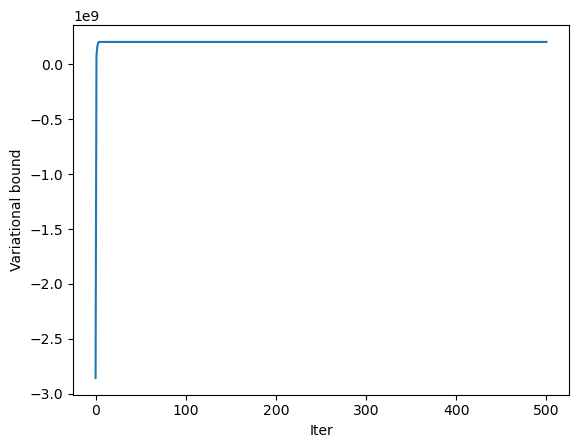

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([200, 200, 20, 24, 3]), device='cuda',
     n_components=50)

In [9]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=verbose, tol=tol)